# Tests Statistiques : Linear Congruential Generator (LCG)

In [13]:
import sys
import os
import math
import numpy as np
from scipy import stats
from collections import Counter

sys.path.append(os.path.abspath('..'))
from generators.lcg import LCG

def shannon_entropy(data):
    probs = [count / len(data) for count in Counter(data).values()]
    return -sum(p * math.log2(p) for p in probs)

def chi_square_uniformity(data):
    expected = len(data) / 256.0
    freqs = [data.count(i) for i in range(256)]
    return stats.chisquare(freqs, f_exp=[expected]*256)

def autocorrelation(data, lag=1):
    x = np.array(data)
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]

def ks_test_uniformity(data):
    normalized = [b / 255.0 for b in data]
    return stats.kstest(normalized, 'uniform')

In [14]:
lcg = LCG(seed=12345)
data_lcg = [lcg.next() % 256 for _ in range(50000)]

print(f"Entropie : {shannon_entropy(data_lcg):.4f} (Idéal: ~8.0)")
print(f"Chi-2    : p-value = {chi_square_uniformity(data_lcg)[1]:.4f} (>0.05 = uniforme)")
print(f"AutoCorr (lag 1) : {autocorrelation(data_lcg, lag=1):.4f} (Idéal: ~0)")
print(f"AutoCorr (lag 8) : {autocorrelation(data_lcg, lag=8):.4f} (Idéal: ~0)")
print(f"Test KS  : p-value = {ks_test_uniformity(data_lcg)[1]:.4f} (>0.05 = uniforme)")

Entropie : 8.0000 (Idéal: ~8.0)
Chi-2    : p-value = 1.0000 (>0.05 = uniforme)
AutoCorr (lag 1) : -0.0496 (Idéal: ~0)
AutoCorr (lag 8) : -0.0018 (Idéal: ~0)
Test KS  : p-value = 0.4248 (>0.05 = uniforme)


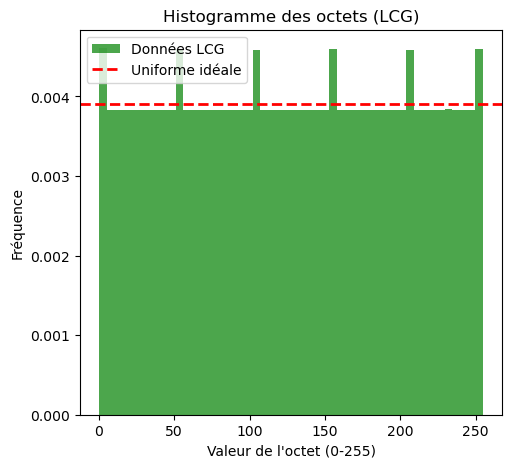

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histogramme d'uniformité
plt.subplot(1, 2, 1)
plt.hist(data_lcg, bins=50, density=True, alpha=0.7, color='green', label="Données LCG")
plt.axhline(y=1/256, color='red', linestyle='dashed', linewidth=2, label="Uniforme idéale")
plt.title("Histogramme des octets (LCG)")
plt.xlabel("Valeur de l'octet (0-255)")
plt.ylabel("Fréquence")
plt.legend()



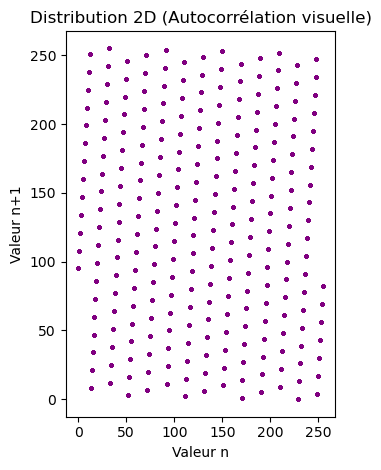

In [16]:
# Nuage de points (x_n vs x_{n+1})
plt.subplot(1, 2, 2)
plt.scatter(data_lcg[:-1], data_lcg[1:], alpha=0.5, s=2, color='purple')
plt.title("Distribution 2D (Autocorrélation visuelle)")
plt.xlabel("Valeur n")
plt.ylabel("Valeur n+1")

plt.tight_layout()
plt.show()

Bien que ce LCG puisse obtenir des scores acceptables sur des tests statistiques unidimensionnels (comme l'entropie ou le KS 1D), il souffre de graves défauts structurels. Dans des dimensions supérieures, ses sorties forment des hyperplans (ce que révèle le test spectral). Surtout, sa relation de récurrence linéaire le rend totalement prévisible, ce qui explique son absence totale de sécurité cryptographique.